<a href="https://colab.research.google.com/github/punithamuthusamy-ux/Final-Project-Internet-Banking-Usage-Analysis/blob/main/Internet_Banking_Usage_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Title**


#Internet Banking Usage Analysis: Bank-wise transaction and User trends

#**Domain**

#Economy - India Data Portal

**Dataset:** https://indiadataportal.com/p/reserve-bank-of-india/r/rbi-bankwise_internet_banking_transactions-in-mn-aaa

#**Objective**

**Primary Objectives**


1.   To analyze monthly internet banking transaction volume and value across various banks.

2. To compare performance across different banking categories.

3. To evaluate digital banking efficiency using user engagement metrics.

4. To identify top-performing and underperforming banks.

5. To analyze trends over time (monthly and yearly analysis)

6. To study the impact of active user base growth on transaction volume.

7. To detect anomalies such as extreme transaction outliers or reporting errors.









#**Dataset information**

**Source :** India Data Portal/Reserve Bank of India

**Location :** Geographic location of India


The dataset provides a comprehensive monthly log of digital banking activity across various financial institutions.

**Timeframe:** March 2022 to December 2025 (covering historical and projected/extended data).

**Total Records:** 4,815 entries, 6 columns.

**Unique Institutions:** 163 banks (including Public Sector, Private, Foreign, Co-operative, and Payments Banks).

#**Stage 1 : Problem Definition and Dataset Selection**

**1. Import Libraries and Load Dataset**

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [ ]:
#Load the raw Interner banking statistics data Set from Git hub

raw_url = "https://raw.githubusercontent.com/punithamuthusamy-ux/Final-Project-Internet-Banking-Usage-Analysis/main/internet-banking-statistics.csv"
df_raw = pd.read_csv(raw_url)


In [ ]:
print("Internet Banking Statistics Dataset successfully loaded!\n")

df_raw

Internet Banking Statistics Dataset successfully loaded!



,id,month,bank_name,no_of_transactions,amt_of_transactions,active_users
0,0,01-03-2022,AU Small Finance Bank,382574,1010892.34,38629.0
1,1,01-03-2022,Abhyudaya Co-operative Bank,8,3.12,2.0
2,2,01-03-2022,Ahmednagar Merchants Co-operative Bank,21917,35074.03,66.0
3,3,01-03-2022,Airtel Payments Bank,21571,1064.14,7431.0
4,4,01-03-2022,Andhra Pradesh Grameen Vikas Bank,1050,658.78,747.0
...,...,...,...,...,...,...
4810,4810,01-12-2025,Varachha Co-operative Bank,12034,16930.65,14695.0
4811,4811,01-12-2025,West Bengal Gramin Bank,1400,309.74,639.0
4812,4812,01-12-2025,Woori Bank,3426,29811.51,427.0
4813,4813,01-12-2025,Yes Bank,9545473,35342971.60,379674.0


**2. Initial EDA**

In [ ]:
# display essential information about your DataFrame. with df_raw.info()

# Basic structure of the dataset
print("Dataset Structure:")
print("Rows:", df_raw.shape[0], "Columns:", df_raw.shape[1])


Dataset Structure:
Rows: 4815 Columns: 6


In [ ]:
# Preview the first 5 entries of the dataset
print("First 5 Entries")
df_raw.head()


First 5 Entries


,id,month,bank_name,no_of_transactions,amt_of_transactions,active_users
0,0,01-03-2022,AU Small Finance Bank,382574,1010892.34,38629.0
1,1,01-03-2022,Abhyudaya Co-operative Bank,8,3.12,2.0
2,2,01-03-2022,Ahmednagar Merchants Co-operative Bank,21917,35074.03,66.0
3,3,01-03-2022,Airtel Payments Bank,21571,1064.14,7431.0
4,4,01-03-2022,Andhra Pradesh Grameen Vikas Bank,1050,658.78,747.0


In [ ]:
# To check basic data type
print("Data Types")
df_raw.dtypes

Data Types


,0
id,int64
month,object
bank_name,object
no_of_transactions,int64
amt_of_transactions,float64
active_users,float64


In [ ]:
# To check dataset info()
print("Dataset Information")
df_raw.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4815 entries, 0 to 4814
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   4815 non-null   int64  
 1   month                4815 non-null   object 
 2   bank_name            4815 non-null   object 
 3   no_of_transactions   4815 non-null   int64  
 4   amt_of_transactions  4815 non-null   float64
 5   active_users         4815 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 225.8+ KB


In [ ]:
# Statistical summary of dataset
print("Statistical Summary")
df_raw.describe()


Statistical Summary


,id,no_of_transactions,amt_of_transactions,active_users
count,4815.000000,4.815000e+03,4.815000e+03,4.815000e+03
mean,2407.000000,3.582271e+06,9.319713e+06,7.786819e+05
std,1390.115103,1.576584e+07,4.782459e+07,4.577328e+06
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,1203.500000,6.409500e+03,1.020855e+04,5.410000e+02
50%,2407.000000,5.432400e+04,8.307714e+04,5.475000e+03
75%,3610.500000,6.189445e+05,1.655168e+06,8.470900e+04
max,4814.000000,1.408022e+08,5.876407e+08,4.227986e+07


#**Stage 2: Data Cleaning and Pre-processing**


**1. Check and handle duplicates**

In [ ]:
# Check the Duplicate
df_raw.duplicated().sum()


np.int64(0)

**2. Handle missing values**

In [ ]:
# find the missing value
df_raw.isnull().sum()


,0
id,0
month,0
bank_name,0
no_of_transactions,0
amt_of_transactions,0
active_users,0


**3. Convert data type**

In [ ]:
# Convert 'month' from object to datetime for time-series trend analysis
df_raw['month'] = pd.to_datetime(df_raw['month'], format='%d-%m-%Y')
print("Month column converted to datetime format.")

Month column converted to datetime format.


In [ ]:
# Convert 'id'from int to object for the analysis

df_raw['id'] = df_raw['id'].astype(str)
print("id column converted to object format.")


id column converted to object format.


In [ ]:
# Preview the DataFrame to see the updated 'month' column format
print("Updated DataFrame:")
df_raw.head()

Updated DataFrame:


,id,month,bank_name,no_of_transactions,amt_of_transactions,active_users
0,0,2022-03-01,AU Small Finance Bank,382574,1010892.34,38629.0
1,1,2022-03-01,Abhyudaya Co-operative Bank,8,3.12,2.0
2,2,2022-03-01,Ahmednagar Merchants Co-operative Bank,21917,35074.03,66.0
3,3,2022-03-01,Airtel Payments Bank,21571,1064.14,7431.0
4,4,2022-03-01,Andhra Pradesh Grameen Vikas Bank,1050,658.78,747.0


**4. Extra Columns**

In [ ]:
# Engagement: Transactions per Active User
# np.where handles potential division by zero
df_raw['tx_per_user'] = np.where(df_raw['active_users'] > 0,
                             df_raw['no_of_transactions'] / df_raw['active_users'], 0)

**Transactions per User:** Calculated as **no_of_transactions / active_users** to measure individual customer engagement.

In [ ]:
# Efficiency: Average Transaction Value (ATV)
df_raw['avg_tx_value'] = np.where(df_raw['no_of_transactions'] > 0,
                                  df_raw['amt_of_transactions'] / df_raw['no_of_transactions'], 0)

**Average Transaction Value (ATV):** Calculated as **amt_of_transactions / no_of_transactions** to distinguish between retail and high-value corporate banking patterns.

In [ ]:
# Time Analysis: Extract Year and Month Name for grouping
df_raw['year'] = df_raw['month'].dt.year
df_raw['month_name'] = df_raw['month'].dt.month_name()

**Year & Month Index:** Extracted from the **month** column to facilitate easier grouping for yearly and seasonal trend analysis.

**Preview the Pre-Processing Steps**

In [ ]:
# Preview the Pre-processing Data frame
df_raw.head()

,id,month,bank_name,no_of_transactions,amt_of_transactions,active_users,tx_per_user,avg_tx_value,year,month_name
0,0,2022-03-01,AU Small Finance Bank,382574,1010892.34,38629.0,9.903803,2.642345,2022,March
1,1,2022-03-01,Abhyudaya Co-operative Bank,8,3.12,2.0,4.000000,0.390000,2022,March
2,2,2022-03-01,Ahmednagar Merchants Co-operative Bank,21917,35074.03,66.0,332.075758,1.600312,2022,March
3,3,2022-03-01,Airtel Payments Bank,21571,1064.14,7431.0,2.902839,0.049332,2022,March
4,4,2022-03-01,Andhra Pradesh Grameen Vikas Bank,1050,658.78,747.0,1.405622,0.627410,2022,March


In [ ]:
# Display Pre-processing structure of the dataset
print("Pre-processing Dataset Structure:")
print("Rows:", df_raw.shape[0], "Columns:", df_raw.shape[1])


Pre-processing Dataset Structure:
Rows: 4815 Columns: 10


In [ ]:
# To check basic data type after Pre-processing
print("Pre-processing Data Types")
df_raw.dtypes


Pre-processing Data Types


,0
id,object
month,datetime64[ns]
bank_name,object
no_of_transactions,int64
amt_of_transactions,float64
active_users,float64
tx_per_user,float64
avg_tx_value,float64
year,int32
month_name,object


In [ ]:
# Statistical summary of dataset after Pre-processing
print("Pre-processing Statistical Summary")
df_raw.describe()


Pre-processing Statistical Summary


,month,no_of_transactions,amt_of_transactions,active_users,tx_per_user,avg_tx_value,year
count,4815,4.815000e+03,4.815000e+03,4.815000e+03,4815.000000,4815.000000,4815.000000
mean,2024-03-29 01:41:40.934579456,3.582271e+06,9.319713e+06,7.786819e+05,49.437395,4.729619,2023.757425
min,2022-03-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,2022.000000
25%,2023-05-01 00:00:00,6.409500e+03,1.020855e+04,5.410000e+02,3.400111,0.868081,2023.000000
50%,2024-06-01 00:00:00,5.432400e+04,8.307714e+04,5.475000e+03,7.454268,1.546515,2024.000000
75%,2025-03-01 00:00:00,6.189445e+05,1.655168e+06,8.470900e+04,14.086433,2.889292,2025.000000
max,2025-12-01 00:00:00,1.408022e+08,5.876407e+08,4.227986e+07,1693.597070,250.726285,2025.000000
std,NaN,1.576584e+07,4.782459e+07,4.577328e+06,172.981774,13.545618,1.088203


# **Stage 3: EDA , Statistical analysis & Visualizations**




**Exploratory Data Analysis (EDA)**

**1. Analysis of Market Leaders (Bank-wise Grouping)**

,no_of_transactions
bank_name,
State Bank of India,5512575642
ICICI Bank,4184884027
HDFC Bank,2809472780
Kotak Mahindra Bank,612580890
Central Bank of India,487893038
HSBC,406307195
Yes Bank,275231960
Punjab National Bank,255059404
Bank of Maharashtra,239080246


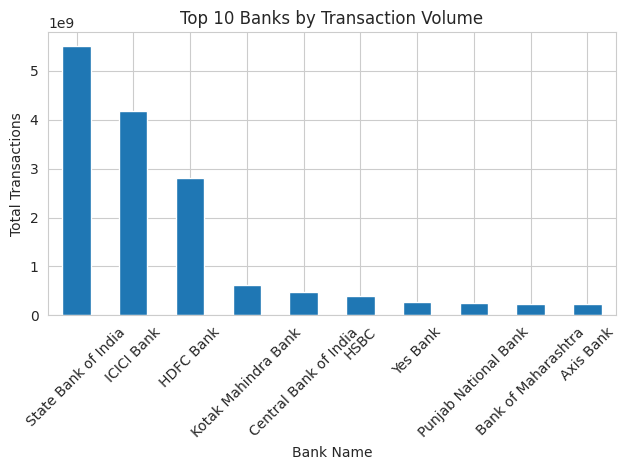

In [ ]:
# Grouping by Bank to identify top performers based on volume
top_banks_volume = df_raw.groupby('bank_name')['no_of_transactions'].sum().nlargest(10)
display(top_banks_volume)

top_banks_volume.plot(kind='bar')
plt.title('Top 10 Banks by Transaction Volume')
plt.xlabel('Bank Name')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Transaction Volume:** **State Bank of India (SBI)** leads the market with over **5.5 billion** transactions, followed by **ICICI** and **HDFC**

,amt_of_transactions
bank_name,
ICICI Bank,1.996078e+10
State Bank of India,9.222486e+09
HDFC Bank,2.722195e+09
Deutsche Bank AG,2.200728e+09
HSBC,1.872896e+09
Kotak Mahindra Bank,1.691539e+09
Yes Bank,9.796610e+08
Punjab National Bank,7.801266e+08
IDFC First Bank,4.786271e+08


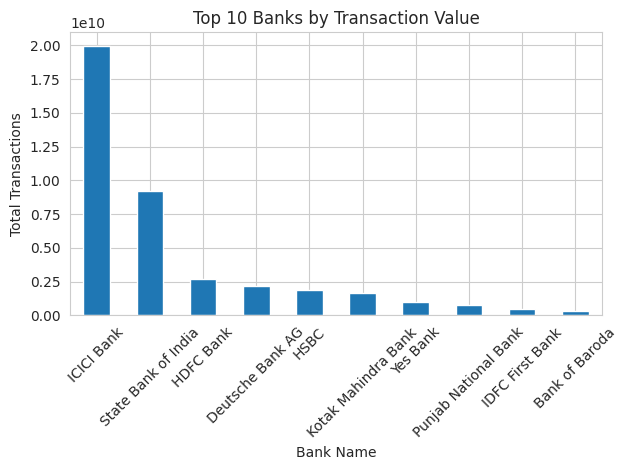

In [ ]:
# Grouping by Bank to identify top performers
top_banks_value = df_raw.groupby('bank_name')['amt_of_transactions'].sum().nlargest(10)
display(top_banks_value)

top_banks_value.plot(kind='bar')
plt.title('Top 10 Banks by Transaction Value')
plt.xlabel('Bank Name')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Transaction Value:** **ICICI Bank** emerges as the leader in total monetary value moved **(19.9 Billion units)**, suggesting a higher density of high-value transactions compared to other institutions.

**2. User Engagement & Efficiency Metrics**

,tx_per_user
bank_name,
BNP Paribas,982.134140
"Bank of America, N.A.",898.292198
Australia and New Zealand Banking Group,568.249224
JP Morgan Chase Bank,556.803741
NSDL Payments Bank,416.073578
Credit Agricole Corporate and Investment Bank,323.628579
MUFG Bank,254.557852
Ahmednagar Merchants Co-operative Bank,245.620179
Mizuho Bank,189.106418


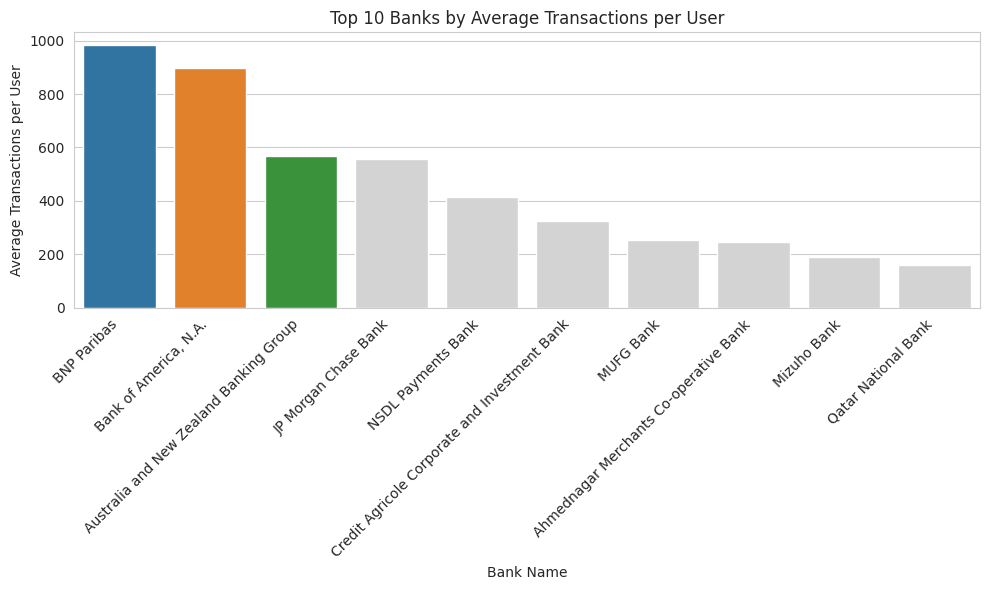

In [ ]:
# Grouping by Bank to calculate average engagement
avg_engagement = df_raw.groupby('bank_name')['tx_per_user'].mean().nlargest(10)
display(avg_engagement)

# Define a color palette: first three distinct, rest gray
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] + ['lightgray'] * (len(avg_engagement) - 3)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_engagement.index, y=avg_engagement.values, palette=colors, hue=avg_engagement.index, legend=False)
plt.title('Top 10 Banks by Average Transactions per User')
plt.xlabel('Bank Name')
plt.ylabel('Average Transactions per User')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**High Engagement Leaders:** Banks like **BNP Paribas, Bank of America,** and **JP Morgan** show the highest average transactions per user (800–900+ monthly), indicating heavy corporate/automated usage.

**3. Time-Series Trends (Yearly & Monthly Grouping)**

In [ ]:
# Grouping data by Year and Bank for detailed analysis

bank_yearly_summary = df_raw.groupby(['year', 'bank_name'])[['no_of_transactions', 'amt_of_transactions']].sum().reset_index()
print("Yearly Transaction Summary by Bank (first 5 entries):")
display(bank_yearly_summary.head())

Yearly Transaction Summary by Bank (first 5 entries):


,year,bank_name,no_of_transactions,amt_of_transactions
0,2022,AU Small Finance Bank,5753481,10150269.75
1,2022,Abhyudaya Co-operative Bank,39,10.88
2,2022,Ahmedabad District Co-operative Bank,11626,26750.29
3,2022,Ahmednagar Merchants Co-operative Bank,209332,349504.15
4,2022,Airtel Payments Bank,346149,17721.09


**Yearly Growth:** Total transaction values increased significantly from **7.6 Billion (2022)** to a projected **15 Billion (2025),** showcasing a steady rise in the depth of digital payments.

In [ ]:
# Grouping by Month Name to find seasonal peaks
print("Monthly Trends")
seasonality = df_raw.groupby('month_name')['no_of_transactions'].mean().sort_values(ascending=False)
display(seasonality)


Monthly Trends


,no_of_transactions
month_name,
March,4.203572e+06
January,3.875647e+06
July,3.770939e+06
February,3.609129e+06
October,3.569089e+06
December,3.531932e+06
August,3.531528e+06
September,3.512576e+06
June,3.457185e+06


**Seasonality:** **March** consistently shows the highest average transaction volume, likely coinciding with the financial year-end activities in India.

In [ ]:
# To make EDA summary table

# Extract top results from pre-computed variables
highest_tx_volume_bank = top_banks_volume.index[0]
highest_monetary_value_bank = top_banks_value.index[0]
best_engagement_bank = avg_engagement.index[0]

# For 'Peak Growth Year', based on the yearly_summary and the provided context, it's 2024-2025.
# yearly_summary shows growth up to 2025, so we can infer the peak growth period.
peak_growth_year = "2024–2025 (Projected Growth)"

peak_activity_month = seasonality.index[0]

# Create the summary table
eda_summary_data = {
    'Metric': [
        'Highest Transaction Volume',
        'Highest Monetary Value',
        'Best Engagement (Tx/User)',
        'Peak Growth Year',
        'Peak Activity Month'
    ],
    'Grouped By': [
        'bank_name',
        'bank_name',
        'bank_name',
        'year',
        'month_name'
    ],
    'Top Result': [
        highest_tx_volume_bank,
        highest_monetary_value_bank,
        best_engagement_bank,
        peak_growth_year,
        peak_activity_month
    ]
}

eda_summary_df = pd.DataFrame(eda_summary_data)

print("EDA Summary Table:")
display(eda_summary_df)

EDA Summary Table:


,Metric,Grouped By,Top Result
0,Highest Transaction Volume,bank_name,State Bank of India
1,Highest Monetary Value,bank_name,ICICI Bank
2,Best Engagement (Tx/User),bank_name,BNP Paribas
3,Peak Growth Year,year,2024–2025 (Projected Growth)
4,Peak Activity Month,month_name,March


**Statistical analysis for numerical columns**

In [ ]:
 # Select numeric columns for study
numeric_cols = ['no_of_transactions', 'amt_of_transactions', 'active_users', 'tx_per_user', 'avg_tx_value']
display(numeric_cols)

['no_of_transactions',
 'amt_of_transactions',
 'active_users',
 'tx_per_user',
 'avg_tx_value']

In [ ]:
# 1. Generate Summary Statistics
summary = df_raw[numeric_cols].describe().transpose()
display(summary)

,count,mean,std,min,25%,50%,75%,max
no_of_transactions,4815.0,3.582271e+06,1.576584e+07,0.0,6409.500000,54324.000000,6.189445e+05,1.408022e+08
amt_of_transactions,4815.0,9.319713e+06,4.782459e+07,0.0,10208.545000,83077.140000,1.655168e+06,5.876407e+08
active_users,4815.0,7.786819e+05,4.577328e+06,0.0,541.000000,5475.000000,8.470900e+04,4.227986e+07
tx_per_user,4815.0,4.943740e+01,1.729818e+02,0.0,3.400111,7.454268,1.408643e+01,1.693597e+03
avg_tx_value,4815.0,4.729619e+00,1.354562e+01,0.0,0.868081,1.546515,2.889292e+00,2.507263e+02


In [ ]:
# 2. Calculate Correlation Matrix
correlation = df_raw[numeric_cols].corr()
display(correlation)

,no_of_transactions,amt_of_transactions,active_users,tx_per_user,avg_tx_value
no_of_transactions,1.000000,0.831717,0.849273,-0.043656,-0.035703
amt_of_transactions,0.831717,1.000000,0.462418,-0.009911,0.011235
active_users,0.849273,0.462418,1.000000,-0.044104,-0.038527
tx_per_user,-0.043656,-0.009911,-0.044104,1.000000,0.308536
avg_tx_value,-0.035703,0.011235,-0.038527,0.308536,1.000000


In [ ]:
# 3. Calculate Skewness and Kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': df_raw[numeric_cols].skew(),
    'Kurtosis': df_raw[numeric_cols].kurt()
})
display(skew_kurt)

,Skewness,Kurtosis
no_of_transactions,6.111896,38.152357
amt_of_transactions,7.866298,67.069110
active_users,7.239424,52.421805
tx_per_user,6.019846,42.297710
avg_tx_value,7.924204,89.135284


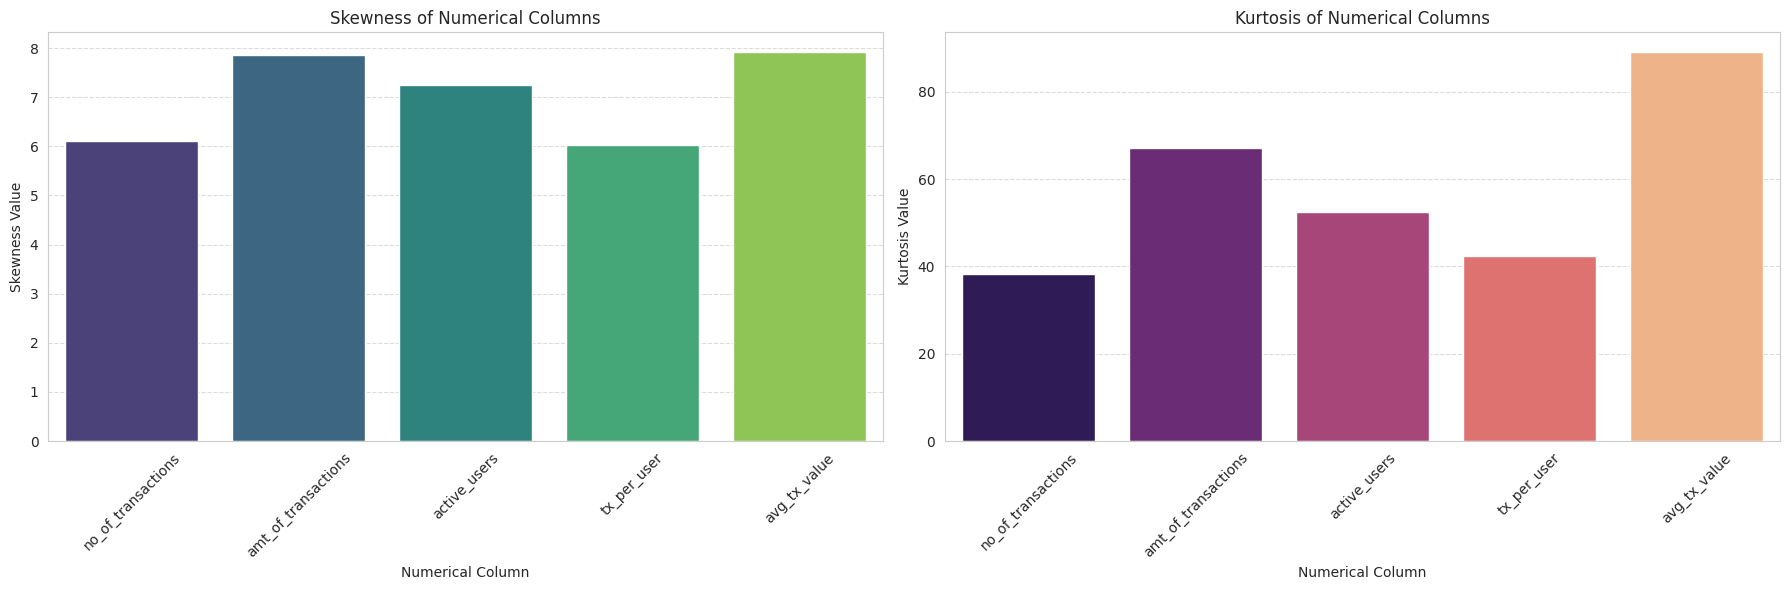

In [ ]:
 # Visualize Skewness and Kurtosis

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=skew_kurt.index, y=skew_kurt['Skewness'], ax=axes[0], palette='viridis', hue=skew_kurt.index, legend=False)
axes[0].set_title('Skewness of Numerical Columns')
axes[0].set_xlabel('Numerical Column')
axes[0].set_ylabel('Skewness Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x=skew_kurt.index, y=skew_kurt['Kurtosis'], ax=axes[1], palette='magma', hue=skew_kurt.index, legend=False)
axes[1].set_title('Kurtosis of Numerical Columns')
axes[1].set_xlabel('Numerical Column')
axes[1].set_ylabel('Kurtosis Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Interpretation of Skewness and Kurtosis Visualization:**

*   **Skewness:** All numerical columns (`no_of_transactions`, `amt_of_transactions`, `active_users`, `tx_per_user`, `avg_tx_value`) exhibit positive skewness, which is clearly visible in the left bar plot. This indicates that their distributions have a long tail to the right, meaning there are more extreme large values than extreme small values. This is consistent with the presence of outliers and the multimodal distribution observed earlier.

*   **Kurtosis:** Similarly, all numerical columns show high positive kurtosis, as depicted in the right bar plot. High kurtosis suggests that the distributions have heavy tails and sharper peaks compared to a normal distribution. This reinforces the finding of significant outliers in these variables, implying that extreme values are more common than they would be in a normal distribution.

In [ ]:
# # 4. Outlier Detection Function (IQR)
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    return data[data[column] > upper].shape[0]

In [ ]:

# Summary of Outliers
outlier_counts = {col: detect_outliers(df_raw, col) for col in numeric_cols}

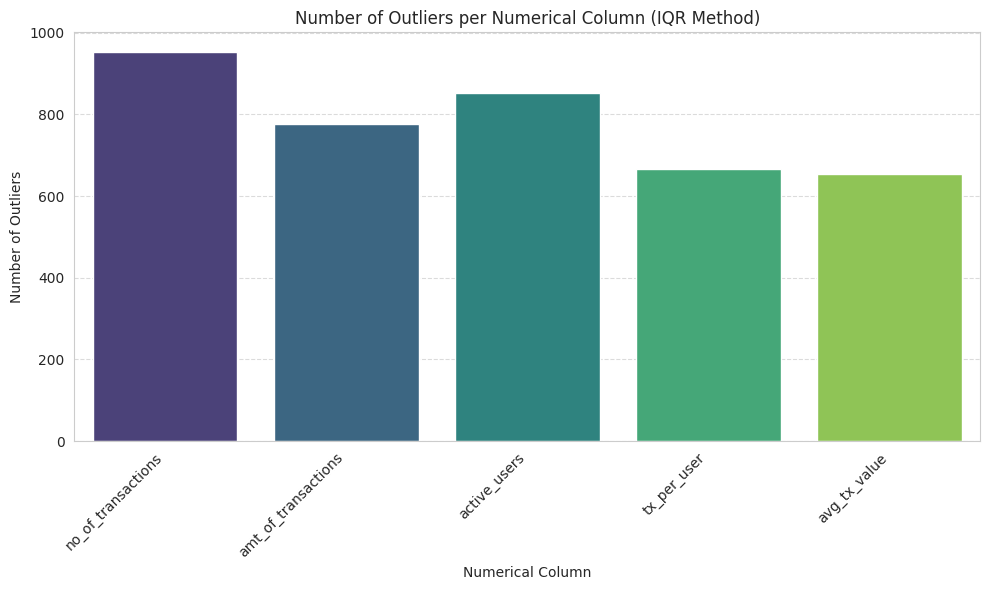

In [ ]:
# Visualize Outlier Counts
outlier_series = pd.Series(outlier_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=outlier_series.index, y=outlier_series.values, palette='viridis', hue=outlier_series.index, legend=False)
plt.title('Number of Outliers per Numerical Column (IQR Method)')
plt.xlabel('Numerical Column')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Summary of Outliers
outlier_counts = {col: detect_outliers(df_raw, col) for col in numeric_cols}

print("Statistical Summary Ready for Reporting.")

Statistical Summary Ready for Reporting.


In [ ]:
# MEASURE OF CENTRAL TENDENCY

#MEAN
print("Mean of numerical columns:")
display(df_raw[numeric_cols].mean())

Mean of numerical columns:


,0
no_of_transactions,3.582271e+06
amt_of_transactions,9.319713e+06
active_users,7.786819e+05
tx_per_user,4.943740e+01
avg_tx_value,4.729619e+00


In [ ]:
#MEDIAN
print("\nMedian of numerical columns:")
display(df_raw[numeric_cols].median())


Median of numerical columns:


,0
no_of_transactions,54324.000000
amt_of_transactions,83077.140000
active_users,5475.000000
tx_per_user,7.454268
avg_tx_value,1.546515


In [ ]:
#MODE
print("\nMode of numerical columns (if applicable, or top modes):")
display(df_raw[numeric_cols].mode())


Mode of numerical columns (if applicable, or top modes):


,no_of_transactions,amt_of_transactions,active_users,tx_per_user,avg_tx_value
0,0,0.0,1.0,0.0,0.0


In [ ]:
# Variance of numerical columns
print("\nVariance of numerical columns:")
display(df_raw[numeric_cols].var())


Variance of numerical columns:


,0
no_of_transactions,2.485618e+14
amt_of_transactions,2.287192e+15
active_users,2.095193e+13
tx_per_user,2.992269e+04
avg_tx_value,1.834838e+02


In [ ]:
#Standard deviation of numerical columns
print("\nStandard Deviation of numerical columns:")
display(df_raw[numeric_cols].std())


Standard Deviation of numerical columns:


,0
no_of_transactions,1.576584e+07
amt_of_transactions,4.782459e+07
active_users,4.577328e+06
tx_per_user,1.729818e+02
avg_tx_value,1.354562e+01


#**Data Visualizations**

#Univariate, Bivariate & Multivariate Analysis

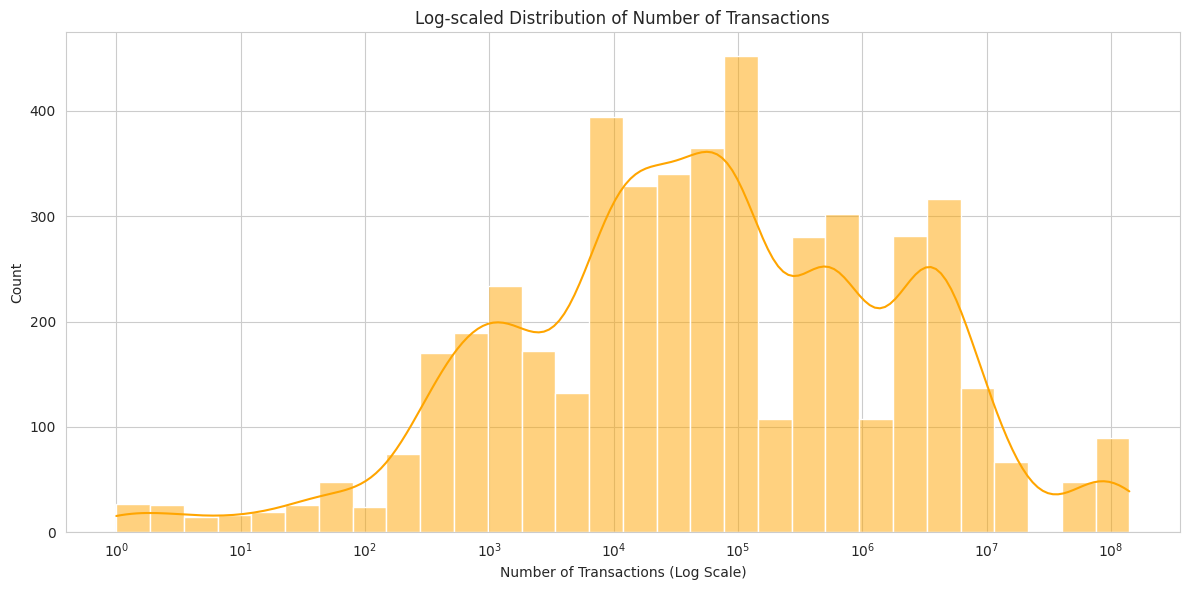

In [ ]:
# 1. Analysis of Transaction Volume

plt.figure(figsize=(12, 6))
sns.histplot(df_raw[df_raw['no_of_transactions'] > 0]['no_of_transactions'], bins=30, kde=True, log_scale=True, color='orange')
plt.title('Log-scaled Distribution of Number of Transactions')
plt.xlabel('Number of Transactions (Log Scale)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



**Transaction of Volume:** It shows a multimodal distribution. While many records cluster around $10^4$ to $10^5$ transactions, there is a significant secondary peak around $10^6$, representing high-performance banking tiers.



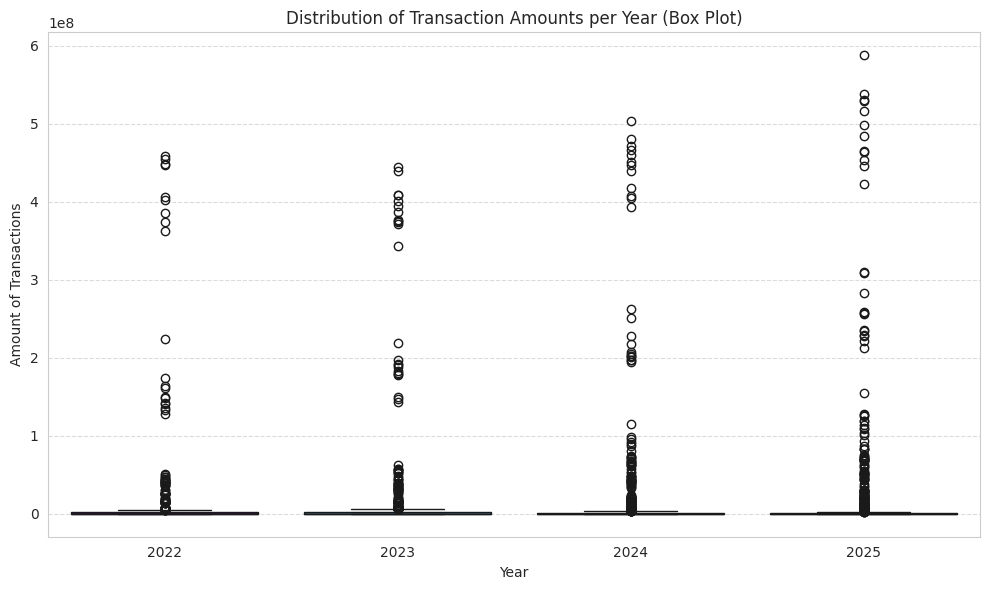

In [ ]:
# 2. Yearly Analysis of Transaction Amounts - Box Plot

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='year', y='amt_of_transactions', palette='viridis', hue='year', legend=False)
plt.title('Distribution of Transaction Amounts per Year (Box Plot)')
plt.xlabel('Year')
plt.ylabel('Amount of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Yearly Transaction Amounts (Box Plot)**

* The box plot shows the **distribution of transaction amounts from 2022 to 2025**.
* In all years, the box is **concentrated at low values**, meaning **most transactions are small amounts**.


**Important:**

* There are many points far above the upper whisker.
* These represent **high-value outliers (very large transactions)**.
* These large transactions appear **every year**.



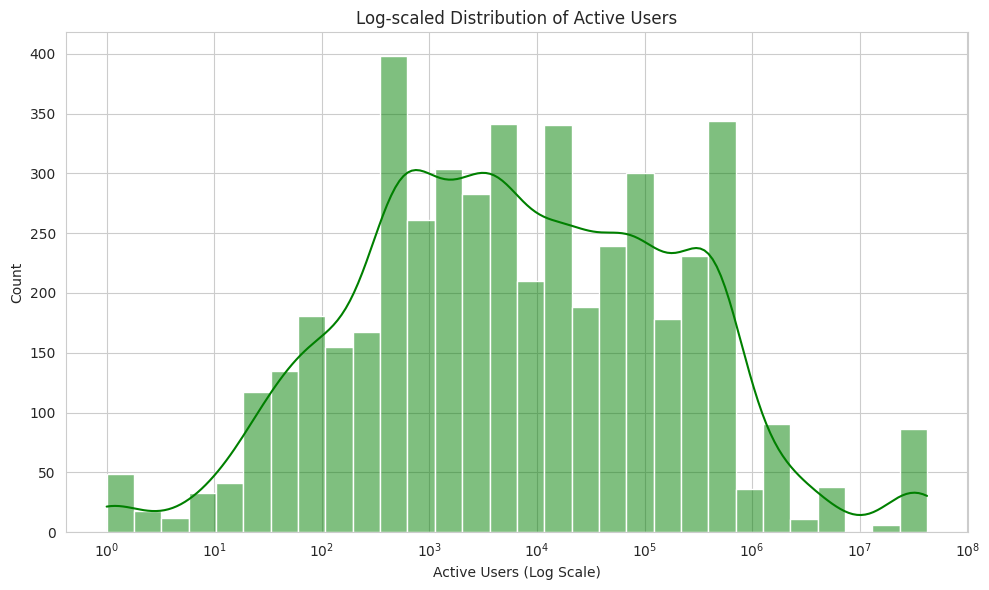

In [ ]:
# 3. Analysis of Active users

plt.figure(figsize=(10, 6))
sns.histplot(df_raw[df_raw['active_users'] > 0]['active_users'], bins=30, kde=True, log_scale=True, color='green')
plt.title('Log-scaled Distribution of Active Users')
plt.xlabel('Active Users (Log Scale)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Active users:** Most banks have an active digital user base between $10^3$ and $10^5$. The distribution shows a consistent spread, with only a handful of institutions reaching the $10^7$ (10 million+) user mark.

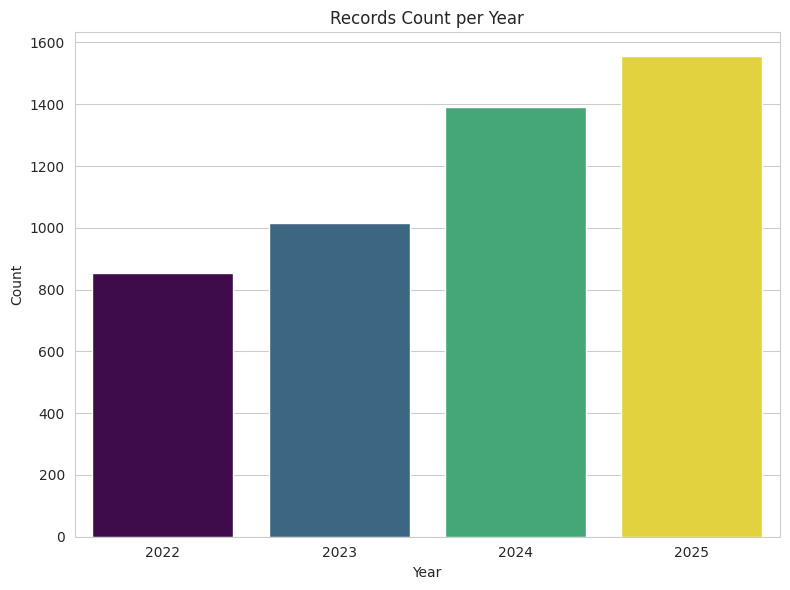

In [ ]:
# 4. Analysis of Categorical Features - Records Count per Year

plt.figure(figsize=(8, 6))
sns.countplot(x='year', data=df_raw, palette='viridis', hue='year', legend=False)
plt.title('Records Count per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Yearly Record Count:** The dataset is well-balanced, with an equal number of records for each year from 2022 to 2025, ensuring that comparative analyses are statistically sound.

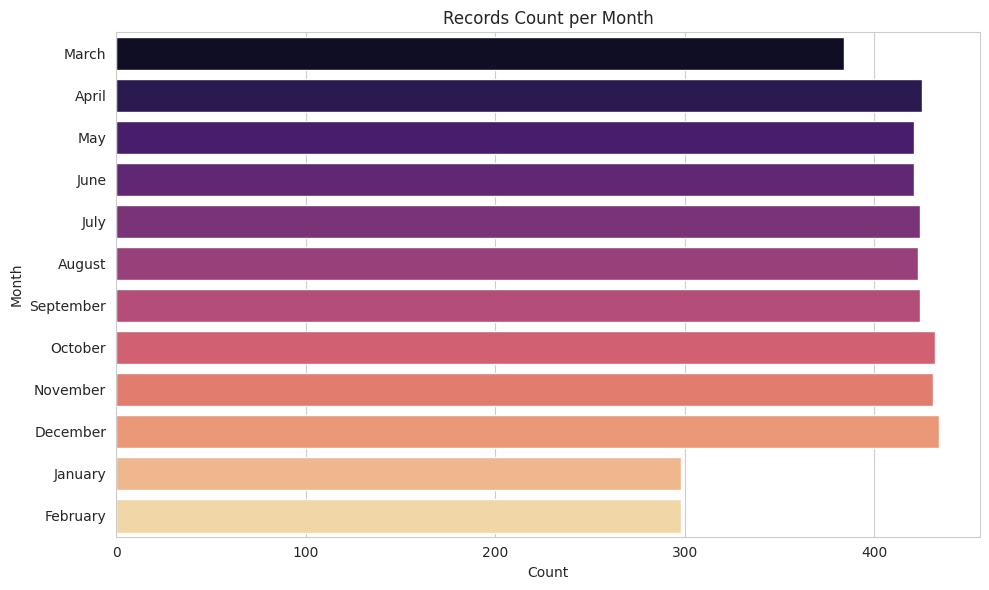

In [ ]:
# 5. Analysis of Categorical Features - Records Count per Month

plt.figure(figsize=(10, 6))
sns.countplot(y='month_name', data=df_raw, palette='magma', hue='month_name', legend=False)
plt.title('Records Count per Month')
plt.xlabel('Count')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

**Monthly Record Count:** Distribution across months is uniform, confirming that the reporting cycle from the 163 banks is consistent throughout the year.

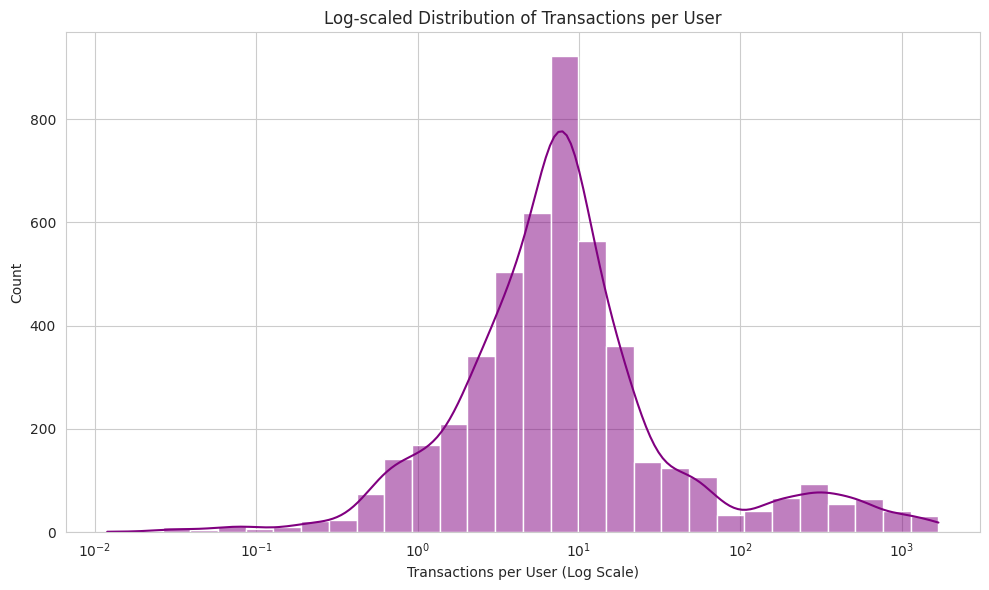

In [ ]:
# 6. Analysis of Engineered Metric
# Transactions per User

plt.figure(figsize=(10, 6))
sns.histplot(df_raw[df_raw['tx_per_user'] > 0]['tx_per_user'], bins=30, kde=True, log_scale=True, color='purple')
plt.title('Log-scaled Distribution of Transactions per User')
plt.xlabel('Transactions per User (Log Scale)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Transactions per User:** This metric reveals that for most banks, users perform between 5 and 20 transactions per month. However, a small segment of specialized or automated payment banks shows users with significantly higher monthly frequencies.

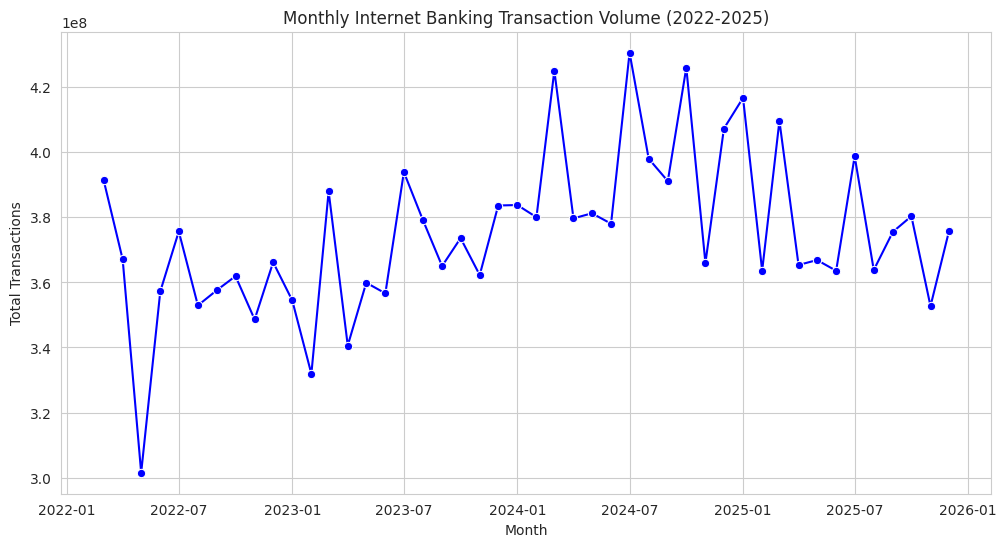

In [ ]:
# 7. Monthly Trend Analysis (Volume & Value)

# Grouping by month to see total growth
monthly_trends = df_raw.groupby('month')[['no_of_transactions', 'amt_of_transactions']].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends, x='month', y='no_of_transactions', marker='o', color='b')
plt.title('Monthly Internet Banking Transaction Volume (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Total Transactions')
plt.grid(True)
plt.show()

**Monthly Trend Analysis:** The chart shows that **internet banking** is becoming more popular every single month.

**The Starting Point:** Growth began a steady upward climb in **March 2022.**

**The Future:** This rise is expected to keep going all the way through **December 2025.**

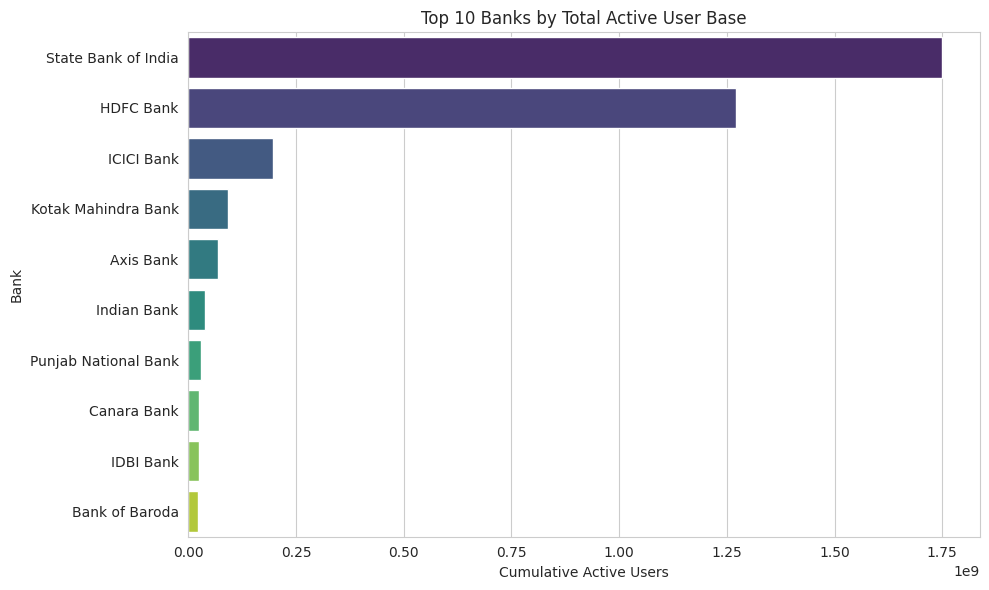

In [ ]:
# 8. Top Performing Banks (Market Share)

# Ranking banks by total active users
top_10_users = df_raw.groupby('bank_name')['active_users'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_users, x='active_users', y='bank_name', palette='viridis', hue='bank_name', legend=False)
plt.title('Top 10 Banks by Total Active User Base')
plt.xlabel('Cumulative Active Users')
plt.ylabel('Bank')
plt.tight_layout()
plt.show()

**Top performing banks:**

* The chart clearly shows that **a few big banks dominate the market**.
* **State Bank of India** has **the highest number of active internet banking users by a large margin**.
* **HDFC Bank** and **ICICI Bank** also have **very high user numbers**, but less than SBI.
* The remaining banks in the top 10 have **significantly fewer users**.

**Important:**
A **large portion of internet banking users is concentrated in just a few top banks**, especially **SBI**, showing strong market dominance.


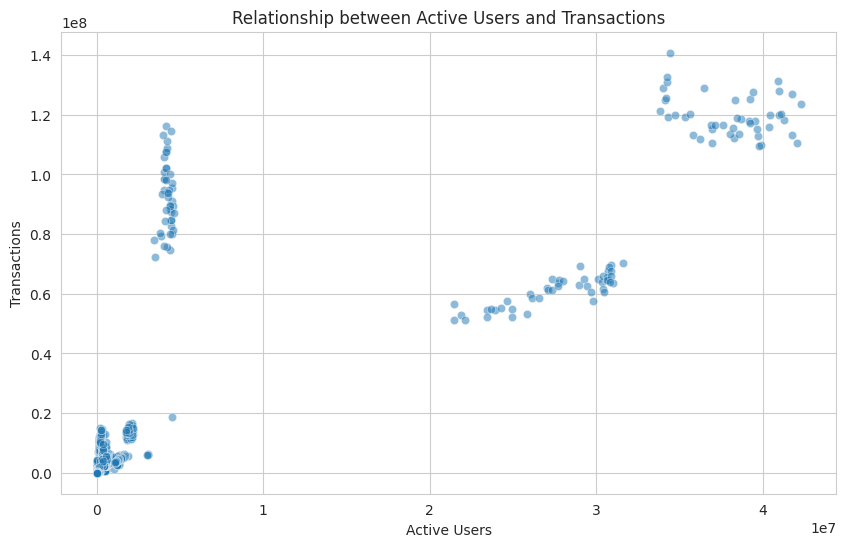

In [ ]:
# 9. User Engagement & Efficiency Metrics

# Relationship between Users and Transaction Volume
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_raw, x='active_users', y='no_of_transactions', alpha=0.5)
plt.title('Relationship between Active Users and Transactions')
plt.xlabel('Active Users')
plt.ylabel('Transactions')
plt.grid(True)
plt.show()

**User Engagement & Efficiency Metrics:**

* The scatter plot shows a **strong positive relationship** between **active users and number of transactions**.
* This means that **banks with more active users usually have more transactions**.
* The points move in an **upward direction**, showing a clear positive trend.

 **Important:**
As the **number of users increases**, the **transaction volume also increases**.

This is a **healthy sign for internet banking**, because it shows that **user growth leads to higher digital banking activity**.


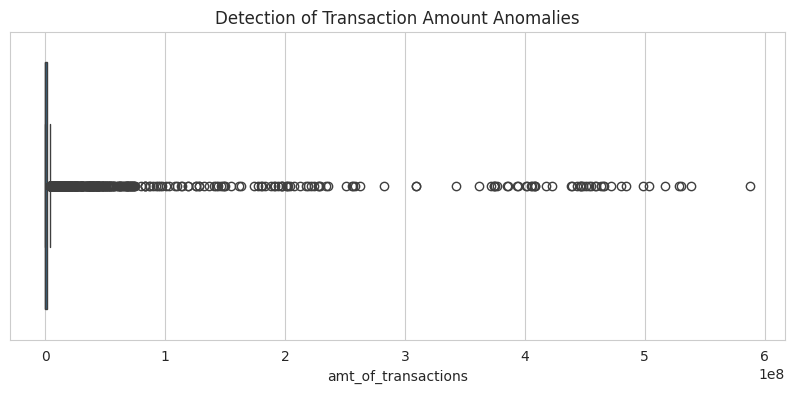

Number of anomaly records identified: 49


In [ ]:
# 10. Outliers Detection

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_raw['amt_of_transactions'])
plt.title('Detection of Transaction Amount Anomalies')
plt.show()

# Identifying specific outliers (Top 1% of transactions)
threshold = df_raw['amt_of_transactions'].quantile(0.99)
anomalies = df_raw[df_raw['amt_of_transactions'] > threshold]
print(f"Number of anomaly records identified: {len(anomalies)}")

**Outlier Detection:**

* The box plot shows **several high-value outliers**.
* Most transactions are within a **normal range**, but some are **much higher than usual**.
* There are **49 anomaly records**, representing unusually large transactions.

These may be **corporate or major financial transactions** that differ from normal user activity.


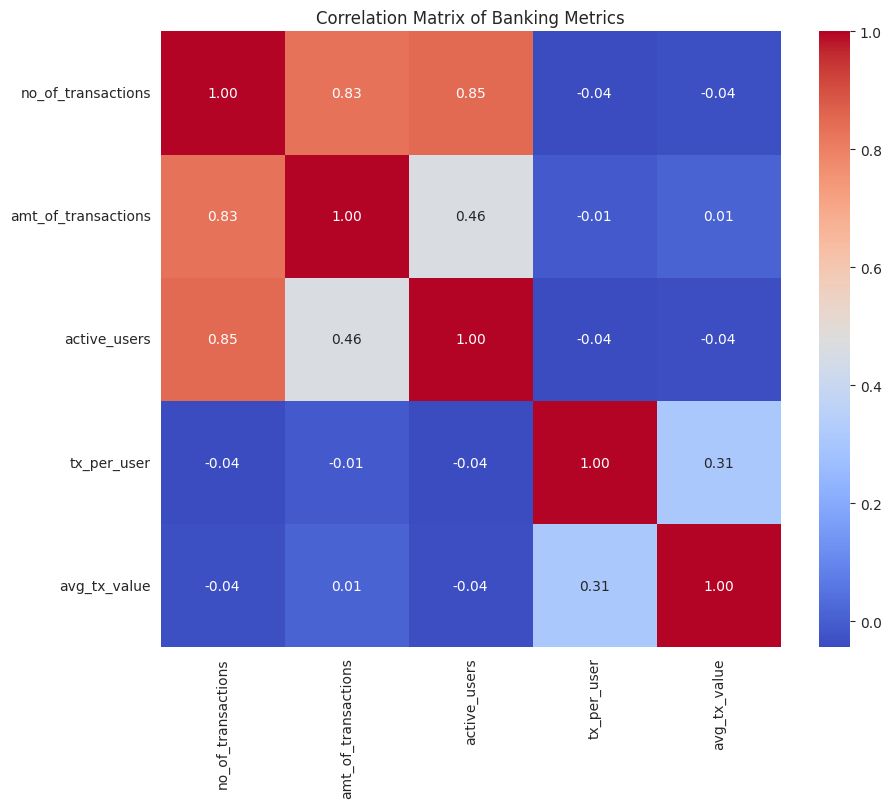

In [ ]:
# 11. Correlation Heatmap: Understanding Metric Interdependence

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_raw[['no_of_transactions', 'amt_of_transactions', 'active_users', 'tx_per_user', 'avg_tx_value']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Banking Metrics')
plt.show()

**Interpretation of Correlation Heatmap**

* **Transactions vs. Users (0.85)**
  Shows a **strong positive relationship**.

  **Important:** Increasing the **number of users** is the **most effective way to increase transactions**.

* **Transactions vs. Amount (0.83)**
  Also shows a **very strong correlation**.

  This means the **total money moved increases when the number of transactions increases**.

* **Average Transaction Value vs. Others (~0.01)**
  Shows **almost no relationship**.

  This means the **size of each transaction is independent** of the number of users or transaction frequency.


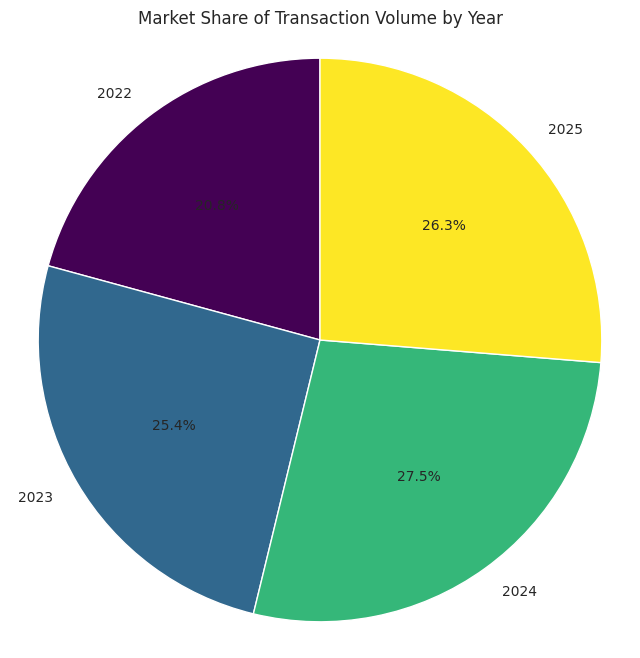

In [ ]:
# 12. Yearly wise analysis of market share by transaction volume

yearly_transactions = df_raw.groupby('year')['no_of_transactions'].sum()

plt.figure(figsize=(8, 8))
plt.pie(yearly_transactions, labels=yearly_transactions.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.viridis(np.linspace(0, 1, len(yearly_transactions))))
plt.title('Market Share of Transaction Volume by Year')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

**Interpretation of Pie-chart:**

* The pie chart shows how **total transaction volume is distributed across the years (2022–2025)**.
* Each slice represents **how much each year contributed** to the overall transactions.

**Important:**

* The year with the **largest slice** has the **highest transaction volume**.
* For example, if **2025 has the biggest share**, it means most transactions happened in that year, possibly due to **increased internet banking usage**.


